#### 1. Imports & Setup

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)

#### 2. Load Dataset

In [33]:
df = pd.read_csv('Housing.csv')
print('Shape:', df.shape)
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,8551000,16500,4,2,2,yes,no,yes,no,yes,1,yes,semi-furnished
1,8238000,15857,5,1,2,yes,yes,no,no,no,0,yes,furnished
2,8145000,15706,3,2,3,yes,yes,no,no,no,2,yes,furnished
3,8095000,14858,4,4,4,yes,no,yes,no,no,3,yes,semi-furnished
4,8049000,16500,2,4,2,yes,no,no,no,yes,0,yes,unfurnished


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [35]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.628662e+06,9344.550459,3.251376,1.609174,1.856881,1.132110
std,1.481313e+06,4394.165233,1.029493,0.778566,0.841083,0.964906
min,1.750000e+06,1714.000000,1.000000,1.000000,1.000000,0.000000
25%,3.444000e+06,5493.000000,3.000000,1.000000,1.000000,0.000000
50%,4.607000e+06,9204.000000,3.000000,1.000000,2.000000,1.000000
75%,5.677000e+06,13103.000000,4.000000,2.000000,2.000000,2.000000
max,8.551000e+06,16500.000000,6.000000,4.000000,4.000000,3.000000


#### 3. Data Cleaning

In [36]:
# Check missing values
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [37]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [38]:
# Unique values for categorical columns
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating','airconditioning', 'prefarea', 'furnishingstatus']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['yes' 'no']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['semi-furnished' 'furnished' 'unfurnished']


#### 4. EDA

###### 4.1 Target Variable Distribution -> Price

In [39]:
import os

os.makedirs("plots", exist_ok=True)

plt.tight_layout()
plt.savefig("plots/price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

In [40]:
plt.tight_layout()
plt.savefig("price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

In [41]:
import os
print(os.getcwd())

c:\Users\ayush\Desktop\House Prediction


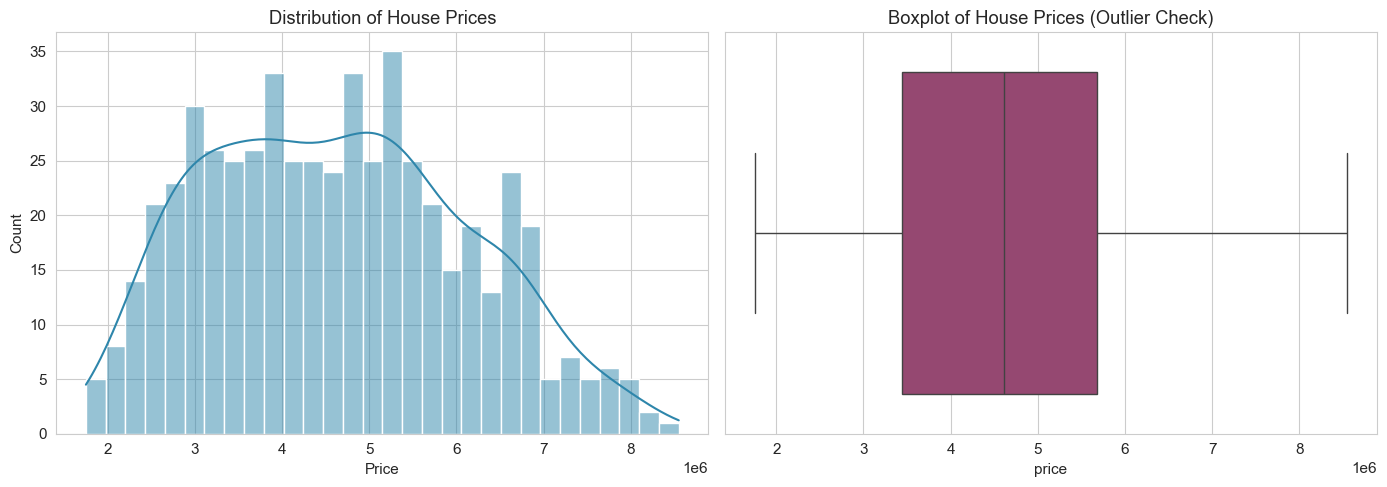

Skewness: 0.252
Kurtosis: -0.740


In [42]:
fig,axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], kde=True, bins=30, color='#2E86AB', ax=axes[0])
axes[0].set_title('Distribution of House Prices')
axes[0].set_xlabel('Price')

sns.boxplot(x=df['price'], color='#A23B72', ax=axes[1])
axes[1].set_title('Boxplot of House Prices (Outlier Check)')

plt.tight_layout()
plt.savefig('plots/price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Skewness: {df['price'].skew():.3f}")
print(f"Kurtosis: {df['price'].kurt():.3f}")


###### 4.2 Numerical Features Distributions

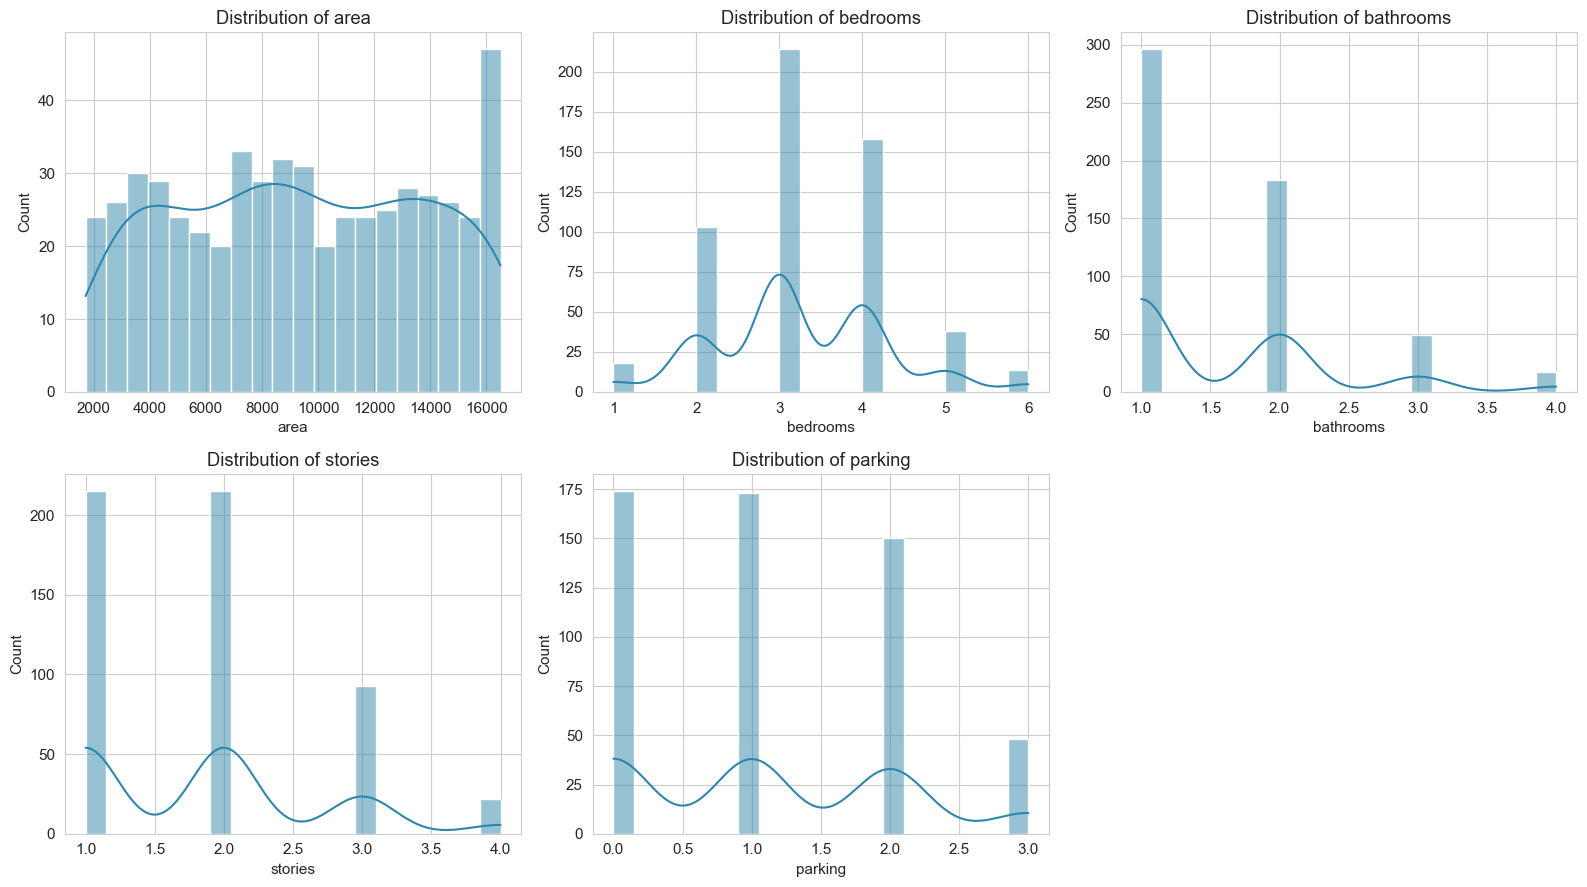

In [43]:
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=20, color='#2E86AB', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('plots/numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.3 Categorical Features Counts

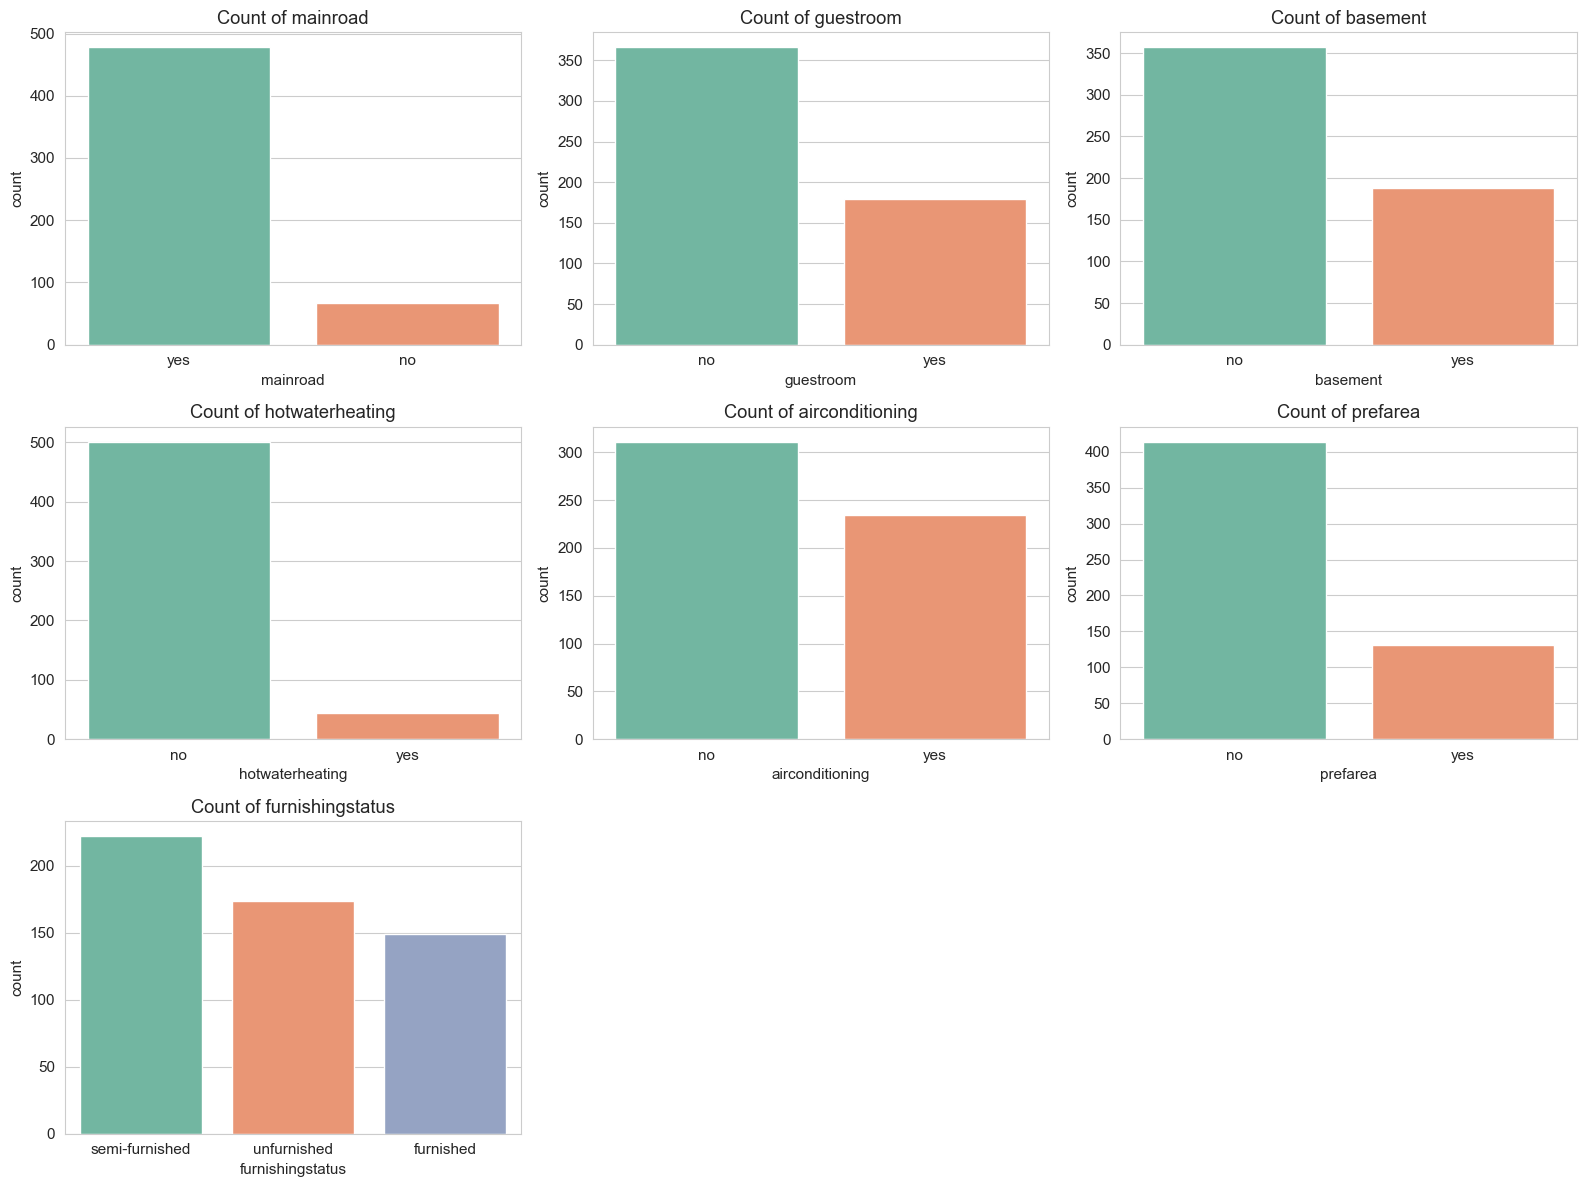

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Count of {col}')
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig('plots/categorical_counts.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.4 Price vs Categorical Features

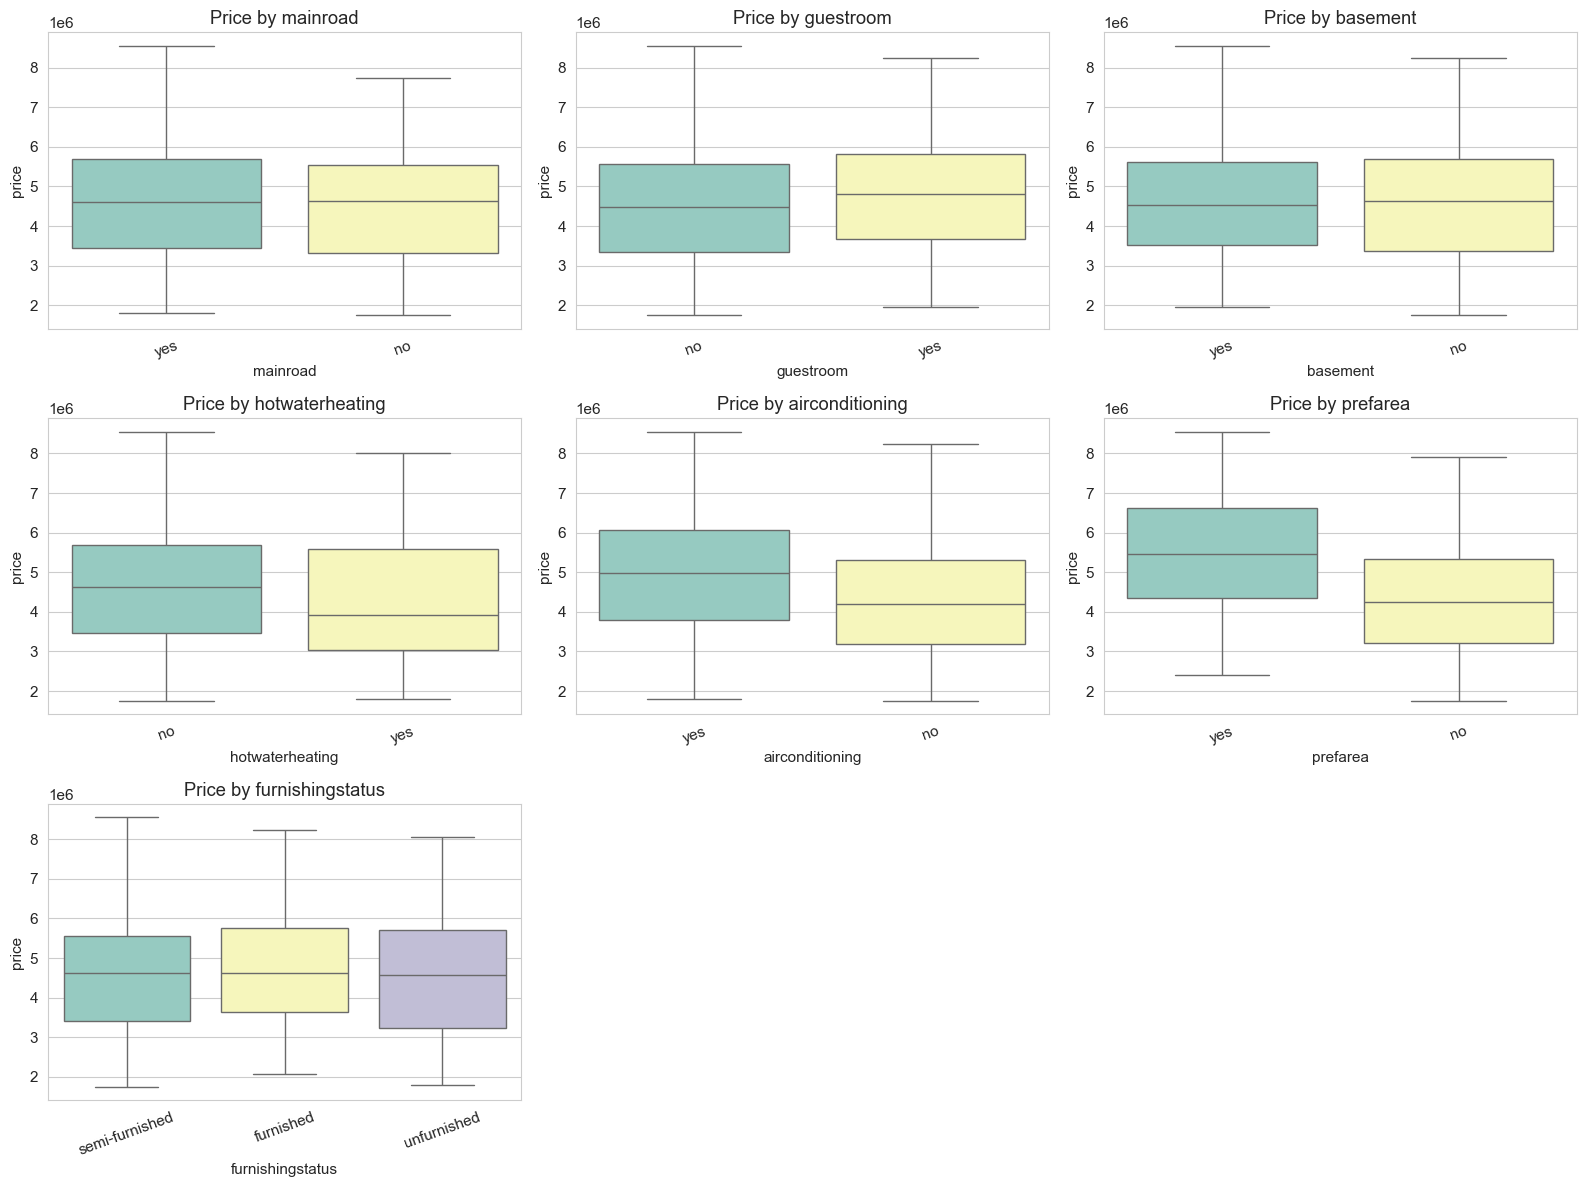

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['price'], palette='Set3', ax=axes[i])
    axes[i].set_title(f'Price by {col}')
    axes[i].tick_params(axis='x', rotation=20)
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig('plots/price_by_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.5 Correlation

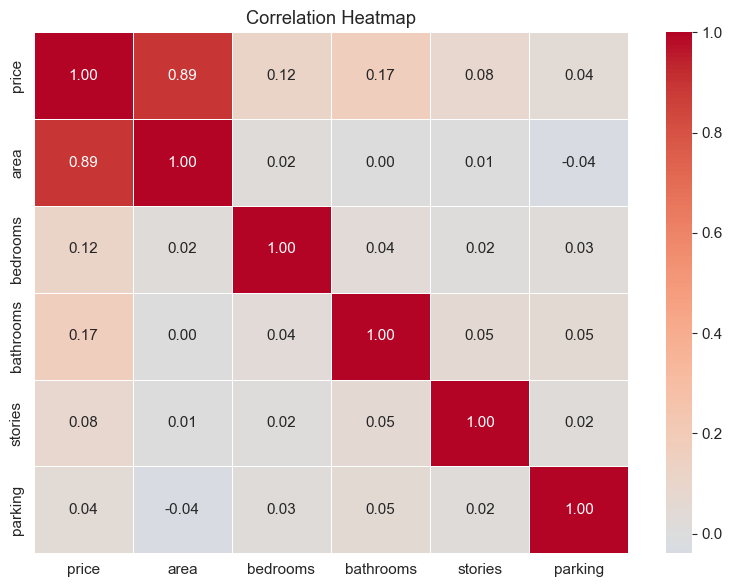

In [46]:
plt.figure(figsize=(8, 6))
corr_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.6 Area vs Price

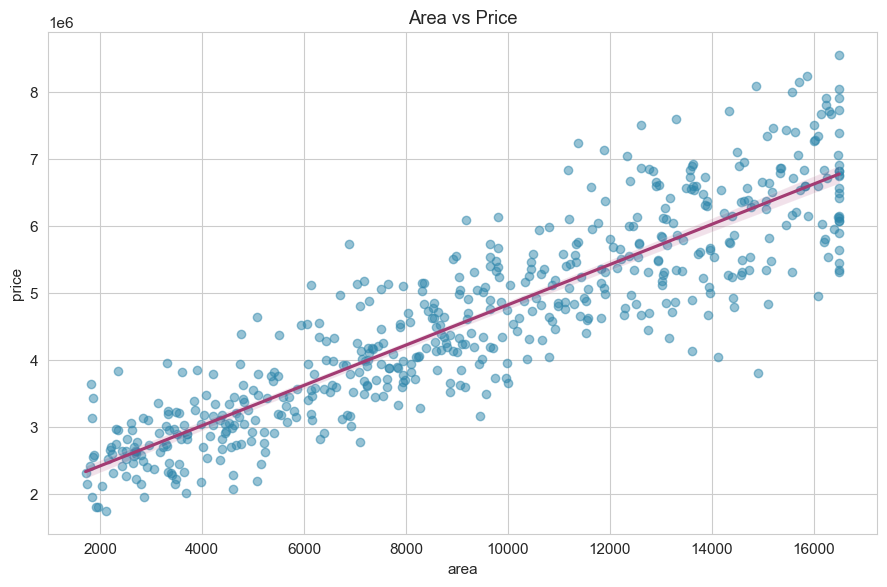

In [47]:
plt.figure(figsize=(9, 6))
sns.regplot(x='area', y='price', data=df, scatter_kws={'alpha': 0.5, 'color': '#2E86AB'},line_kws={'color': '#A23B72'})
plt.title('Area vs Price')
plt.tight_layout()
plt.savefig('plots/area_vs_price.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.7 Pairplot of Key Numerical Features

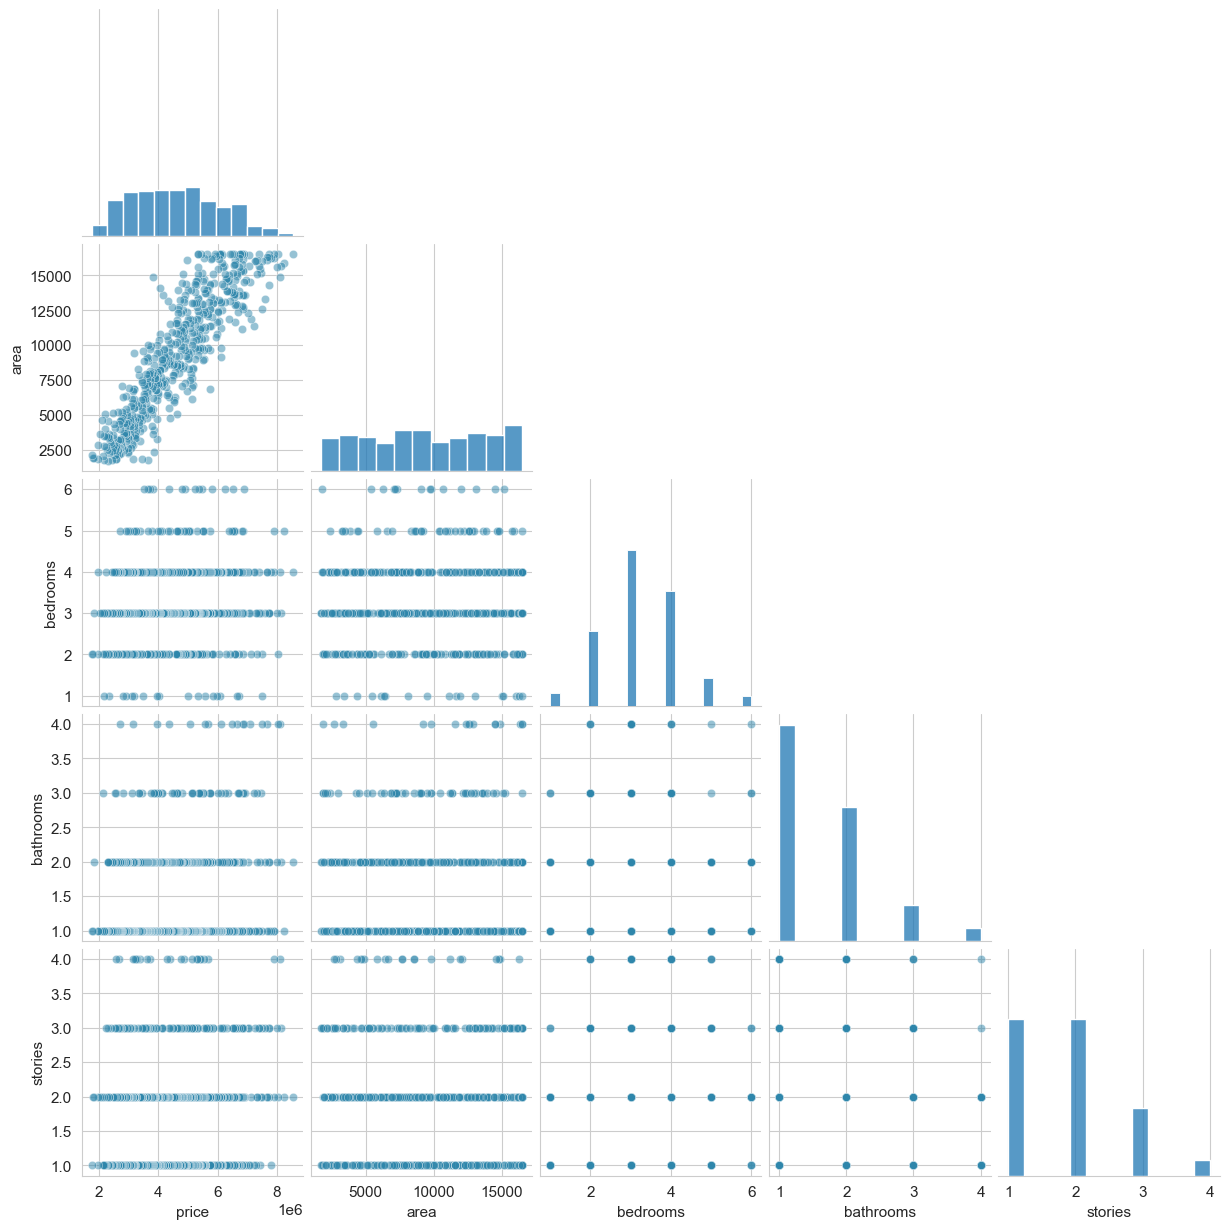

In [48]:
sns.pairplot(df[['price', 'area', 'bedrooms', 'bathrooms', 'stories']], corner=True,plot_kws={'alpha': 0.5, 'color': '#2E86AB'})
plt.savefig('plots/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.8 Average Price by Bedrooms & Furnishing Status

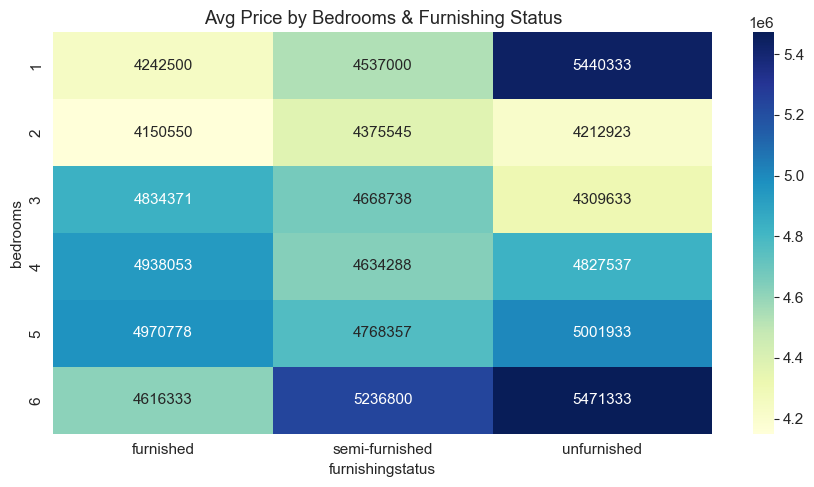

In [49]:
pivot = df.pivot_table(values='price', index='bedrooms', columns='furnishingstatus', aggfunc='mean')
plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Avg Price by Bedrooms & Furnishing Status')
plt.tight_layout()
plt.savefig('plots/price_bedrooms_furnishing.png', dpi=120, bbox_inches='tight')
plt.show()

#### 5. Feature Engineering

In [50]:
data = df.copy()

# Binary yes/no columns -> 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:data[col] = data[col].map({'yes': 1, 'no': 0})

# Derived features
data['total_rooms'] = data['bedrooms'] + data['bathrooms']
data['area_per_room'] = data['area'] / data['total_rooms']
data['amenity_score'] = data[binary_cols].sum(axis=1)
data['is_luxury'] = ((data['airconditioning'] == 1) & (data['prefarea'] == 1) & (data['furnishingstatus'] == 'furnished')).astype(int)
data.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_room,amenity_score,is_luxury
0,8551000,16500,4,2,2,1,0,1,0,1,1,1,semi-furnished,6,2750.000000,4,0
1,8238000,15857,5,1,2,1,1,0,0,0,0,1,furnished,6,2642.833333,3,0
2,8145000,15706,3,2,3,1,1,0,0,0,2,1,furnished,5,3141.200000,3,0
3,8095000,14858,4,4,4,1,0,1,0,0,3,1,semi-furnished,8,1857.250000,3,0
4,8049000,16500,2,4,2,1,0,0,0,1,0,1,unfurnished,6,2750.000000,3,0


In [51]:
# EDA-only feature (not fed to the model -- would leak target information)
df['price_per_sqft'] = df['price'] / df['area']
print(df.groupby('furnishingstatus')['price_per_sqft'].mean().sort_values(ascending=False))

furnishingstatus
semi-furnished    587.149648
furnished         580.750399
unfurnished       553.013981
Name: price_per_sqft, dtype: float64


###### 5.1 Encode Furnishing Stats

In [52]:
le_furnishing = LabelEncoder()
data['furnishingstatus'] = le_furnishing.fit_transform(data['furnishingstatus'])
print(dict(zip(le_furnishing.classes_, le_furnishing.transform(le_furnishing.classes_))))
data.head()


{'furnished': np.int64(0), 'semi-furnished': np.int64(1), 'unfurnished': np.int64(2)}


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_room,amenity_score,is_luxury
0,8551000,16500,4,2,2,1,0,1,0,1,1,1,1,6,2750.000000,4,0
1,8238000,15857,5,1,2,1,1,0,0,0,0,1,0,6,2642.833333,3,0
2,8145000,15706,3,2,3,1,1,0,0,0,2,1,0,5,3141.200000,3,0
3,8095000,14858,4,4,4,1,0,1,0,0,3,1,1,8,1857.250000,3,0
4,8049000,16500,2,4,2,1,0,0,0,1,0,1,2,6,2750.000000,3,0


###### 5.2 New Feature Correlation with Price

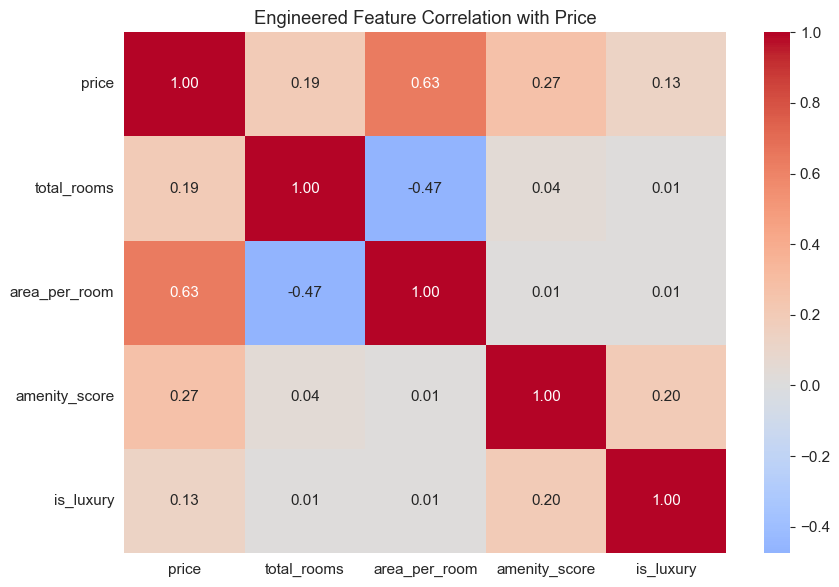

In [53]:
plt.figure(figsize=(9, 6))
engineered = ['price', 'total_rooms', 'area_per_room', 'amenity_score', 'is_luxury']
sns.heatmap(data[engineered].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Engineered Feature Correlation with Price')
plt.tight_layout()
plt.savefig('plots/engineered_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

#### 6. Train-Test Split

In [54]:
FEATURES = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom','basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea','furnishingstatus', 'total_rooms', 'area_per_room', 'amenity_score', 'is_luxury']
TARGET = 'price'

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (436, 16), Test shape: (109, 16)


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


##### 7. Model Training

In [56]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=100),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=6),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=200, verbosity=0),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Ridge,323799.451798,448522.754709,0.930740
1,Lasso,325089.892547,450274.082290,0.930198
2,Linear Regression,325186.738776,450394.488458,0.930160
3,Random Forest,380359.587156,504488.469345,0.912377
4,Gradient Boosting,371188.394996,505486.642541,0.912030
5,XGBoost,409291.125000,547825.704486,0.896676
6,Decision Tree,438229.869341,578291.380769,0.884864


###### 7.1 Model Comparison Chart

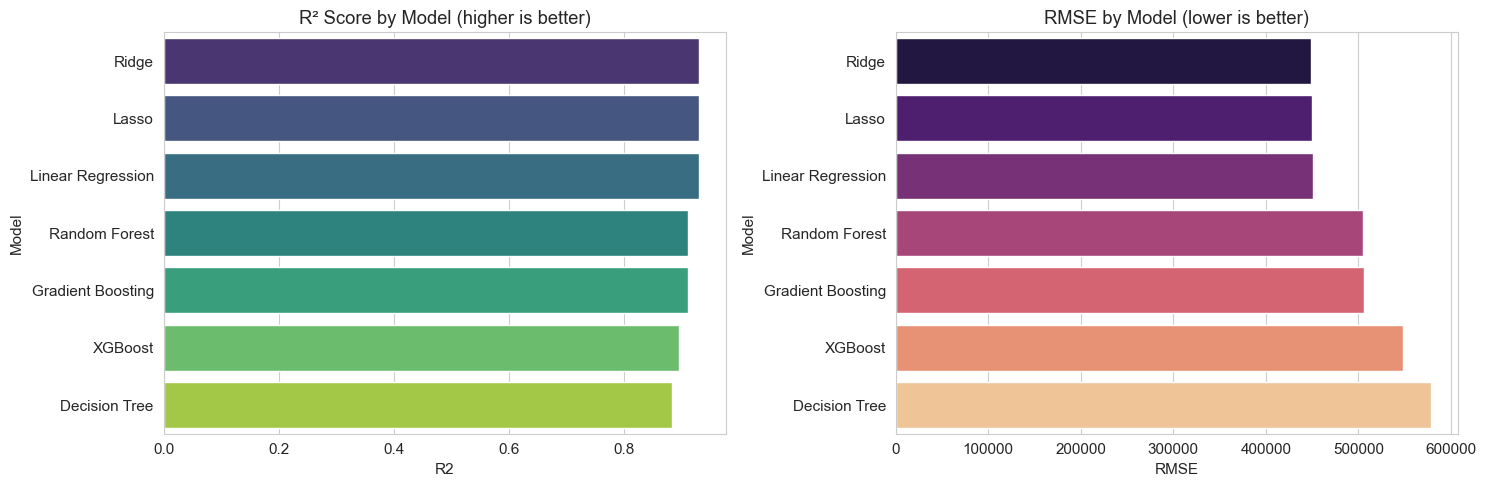

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=results_df, x='R2', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('R² Score by Model (higher is better)')
sns.barplot(data=results_df, x='RMSE', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('RMSE by Model (lower is better)')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


#### 8. Hyperparameter Tuning

In [58]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(
    xgb, param_grid, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R²: 0.8700814127922059


In [59]:
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Tuned XGBoost — MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R²: {r2:.4f}")

Tuned XGBoost — MAE: 356,574 | RMSE: 486,676 | R²: 0.9185


###### 9. Model Evaluation

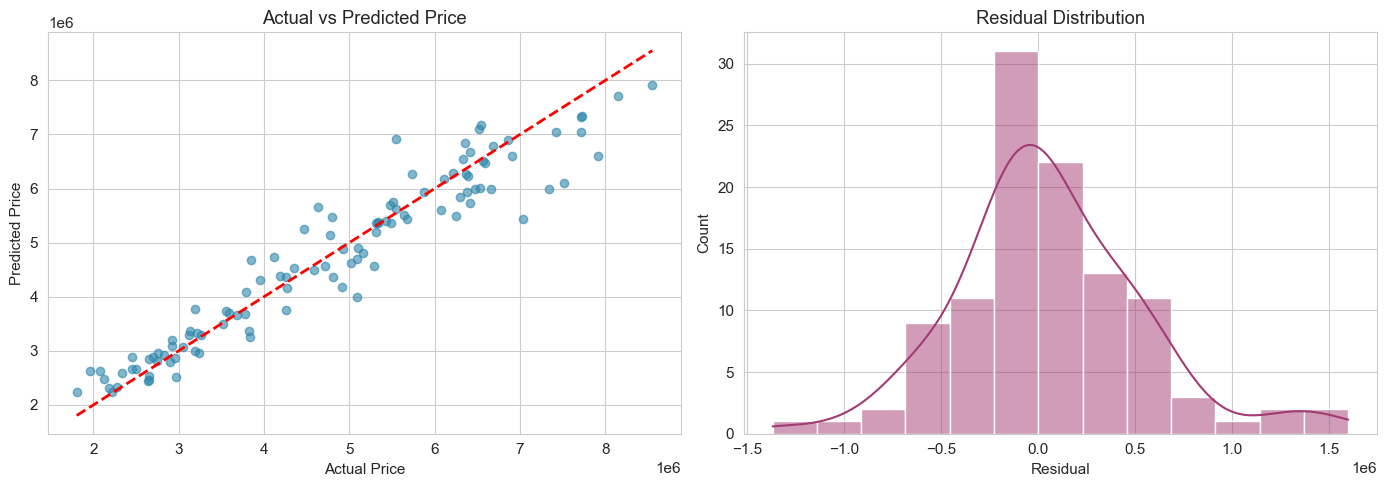

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds, alpha=0.6, color='#2E86AB')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted Price')

residuals = y_test - preds
sns.histplot(residuals, kde=True, color='#A23B72', ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('plots/model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

###### 9.1 Feature Importance

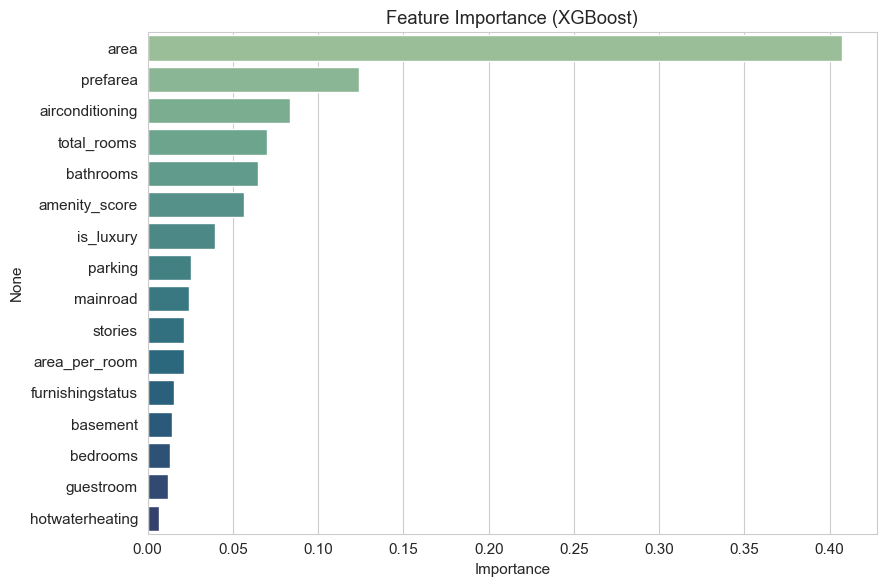

In [61]:
importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, palette='crest')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


#### 10. Save Artifacts

In [65]:
joblib.dump(best_model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_furnishing, 'furnishing_encoder.pkl')
joblib.dump(FEATURES, 'feature_columns.pkl')

print("Artifacts saved:")
print("- house_price_model.pkl")
print("- scaler.pkl")
print("- furnishing_encoder.pkl")
print("- feature_columns.pkl")


Artifacts saved:
- house_price_model.pkl
- scaler.pkl
- furnishing_encoder.pkl
- feature_columns.pkl
